In [1]:
!pip install kaggle

from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rakshanamaids","key":"48cb50ca6a6564517a6598cc535e819b"}'}

In [2]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle competitions download -c data-sprint-veri
!unzip data-sprint-veri.zip

Streaming output truncated to the last 5000 lines.
  inflating: VeRi/image_train/0665_c012_00062310_0.jpg  
  inflating: VeRi/image_train/0665_c012_00062320_0.jpg  
  inflating: VeRi/image_train/0665_c012_00062325_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062110_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062115_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062120_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062125_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062130_0.jpg  
  inflating: VeRi/image_train/0665_c013_00062135_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063935_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063940_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063945_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063950_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063955_0.jpg  
  inflating: VeRi/image_train/0665_c014_00063960_0.jpg  
  inflating: VeRi/image_train/0665_c015_00063745_0.jpg  
  inflating: VeRi/image_train/0665_c0

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import os, cv2
import numpy as np

In [5]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

In [8]:
class VeriDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

        self.id_to_images = {}
        for path in image_paths:
            vid = path.split('/')[-1].split('_')[0]
            if vid not in self.id_to_images:
                self.id_to_images[vid] = []
            self.id_to_images[vid].append(path)

        self.ids = list(self.id_to_images.keys())

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img1_path = self.image_paths[idx]
        vid = img1_path.split('/')[-1].split('_')[0]

        # Positive or negative
        if np.random.rand() > 0.5:
            img2_path = np.random.choice(self.id_to_images[vid])
            label = 1
        else:
            neg_id = np.random.choice(self.ids)
            while neg_id == vid:
                neg_id = np.random.choice(self.ids)
            img2_path = np.random.choice(self.id_to_images[neg_id])
            label = 0

        img1 = cv2.imread(img1_path)
        img2 = cv2.imread(img2_path)

        img1 = cv2.resize(img1, (128,128))
        img2 = cv2.resize(img2, (128,128))

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(label, dtype=torch.float32)

In [15]:
import os

image_folder = "VeRi/image_train"

image_paths = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.endswith(".jpg")
]

print(len(image_paths))  # should be ~37778

37778


In [16]:
dataset = VeriDataset(image_paths, transform)
print(len(dataset))  # should be same

37778


In [17]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [18]:
print(len(dataset))

37778


In [9]:
import os
print(os.listdir('VeRi'))

['camera_Dist.txt', 'gt_index.txt', 'image_train', 'test_label.xml', 'name_train.txt', 'image_test', 'image_query', 'YongtaiPoint_Google.jpg', 'ReadMe.txt', 'train_label.xml', 'jk_index.txt', 'list_type.txt', 'test_track_VeRi.txt', 'camera_ID.txt', 'list_color.txt', 'test_track.txt', 'name_test.txt', 'name_query.txt']


In [12]:
import os
print(len(os.listdir("VeRi/image_train")))

37778


In [13]:
print(os.listdir("VeRi/image_train"))

['0620_c010_00072430_0.jpg', '0474_c008_00014035_1.jpg', '0054_c015_00001630_0.jpg', '0164_c004_00000050_0.jpg', '0274_c001_00035490_0.jpg', '0462_c001_00017440_0.jpg', '0353_c019_00082115_0.jpg', '0613_c001_00081030_0.jpg', '0757_c016_00021475_0.jpg', '0282_c006_00030965_0.jpg', '0367_c009_00004230_0.jpg', '0766_c016_00078690_0.jpg', '0018_c017_00053415_0.jpg', '0745_c002_00023345_0.jpg', '0330_c005_00049660_0.jpg', '0232_c019_00083100_0.jpg', '0613_c011_00003530_1.jpg', '0536_c013_00014095_0.jpg', '0350_c014_00016250_0.jpg', '0041_c013_00039395_1.jpg', '0578_c004_00024745_0.jpg', '0022_c007_00072950_0.jpg', '0119_c013_00028200_0.jpg', '0163_c015_00014365_0.jpg', '0075_c009_00033000_0.jpg', '0366_c004_00081130_0.jpg', '0348_c007_00028395_0.jpg', '0094_c015_00000270_0.jpg', '0491_c006_00062280_1.jpg', '0535_c008_00022870_0.jpg', '0472_c003_00013605_0.jpg', '0167_c015_00018545_0.jpg', '0715_c008_00014700_0.jpg', '0594_c001_00083005_0.jpg', '0047_c011_00066345_1.jpg', '0539_c011_00071525

In [14]:
for root, dirs, files in os.walk("VeRi"):
    print(root, len(files))

VeRi 15
VeRi/image_train 37778
VeRi/image_test 11579
VeRi/image_query 1678


In [10]:
dataset = VeriDataset("VeRi/image_train", transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

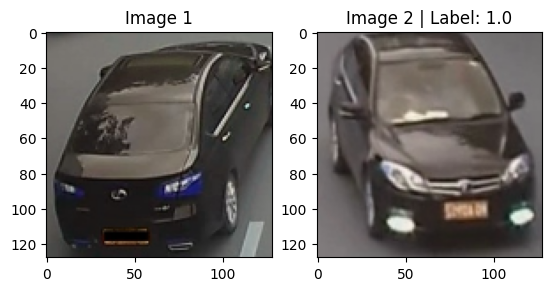

In [20]:
import matplotlib.pyplot as plt

img1, img2, label = dataset[0]

plt.subplot(1,2,1)
plt.imshow(img1.permute(1,2,0))
plt.title("Image 1")

plt.subplot(1,2,2)
plt.imshow(img2.permute(1,2,0))
plt.title(f"Image 2 | Label: {label.item()}")

plt.show()

In [21]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,128)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)

        # 🔥 VERY IMPORTANT (NORMALIZATION)
        x = x / x.norm(p=2, dim=1, keepdim=True)

        return x

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import os

base_path = "/content/drive/MyDrive/Datasprint_Submission"

os.makedirs(base_path, exist_ok=True)

print("Folder created:", base_path)

Folder created: /content/drive/MyDrive/Datasprint_Submission


In [24]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,128)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)

        # 🔥 important for Re-ID
        x = x / x.norm(p=2, dim=1, keepdim=True)

        return x

In [28]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,128)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        x = x / x.norm(p=2, dim=1, keepdim=True)
        return x

In [29]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CNNEncoder()

    def forward(self, x1, x2):
        f1 = self.encoder(x1)
        f2 = self.encoder(x2)
        return f1, f2

In [30]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, f1, f2, label):
        distance = torch.nn.functional.pairwise_distance(f1, f2)
        loss = label * distance**2 + \
               (1-label) * torch.clamp(self.margin-distance, min=0)**2
        return loss.mean()

In [31]:
def save_checkpoint(model, optimizer, epoch, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, path)


def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    print(f"Resuming from epoch {start_epoch}")

    return start_epoch

In [32]:
import torch
print("Using device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

Using device: cuda


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SiameseNetwork().to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(model.parameters(), lr=0.0003)

checkpoint_path = base_path + "/checkpoint.pth"

start_epoch = 0

# Resume if exists
if os.path.exists(checkpoint_path):
    start_epoch = load_checkpoint(model, optimizer, checkpoint_path)

EPOCHS = 50

for epoch in range(start_epoch, EPOCHS):
    total_loss = 0

    for img1, img2, label in dataloader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        f1, f2 = model(img1, img2)
        loss = criterion(f1, f2, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}")

    # Save checkpoint every epoch
    save_checkpoint(model, optimizer, epoch, checkpoint_path)

# Save final model
torch.save(model.state_dict(), base_path + "/model.pkl")

print("✅ Training complete")

Resuming from epoch 3
Epoch 4/50, Loss: 118.2019
Epoch 5/50, Loss: 114.5630
Epoch 6/50, Loss: 112.4948
Epoch 7/50, Loss: 106.9500
Epoch 8/50, Loss: 103.8996
Epoch 9/50, Loss: 103.1379
Epoch 10/50, Loss: 98.7485
Epoch 11/50, Loss: 96.0585
Epoch 12/50, Loss: 95.4183
Epoch 13/50, Loss: 92.6323
Epoch 14/50, Loss: 93.0243
Epoch 15/50, Loss: 89.9622
Epoch 16/50, Loss: 89.5317
Epoch 17/50, Loss: 87.4091
Epoch 18/50, Loss: 86.8827
Epoch 19/50, Loss: 84.2145
Epoch 20/50, Loss: 83.5949
Epoch 21/50, Loss: 82.2870
